# 文本评论与三元组网络分析

本分析笔记已整理为**可从上至下一次性运行**的流程，主要包含以下模块：

1. 环境与参数设置
2. 评论数据读取与预处理
3. 原始评论的时间—语义联合降权
4. 贝叶斯优化搜索时间窗口与 $\alpha$
5. 基于 $W_i$ 的评论赋权词云
6. 基于三元组的有向关系网络
7. 基于 Louvain 的社区发现与可视化
8. 前 5 个社区的主题命名与代表关系摘要

运行建议：
- 直接按顺序执行全部单元；
- 原始评论文件默认为同目录下的 `merged_comments.csv`；
- 图表与结果文件将保存到 `outputs/` 目录；
- 若需重新生成文本嵌入缓存，可将 `FORCE_REBUILD_EMBEDDINGS` 设为 `True`。

In [ ]:
import json
import re
import time
import warnings
from pathlib import Path

import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import display
from cycler import cycler
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# 全局风格
# ---------------------------------------------------------------------------
青橙灰配色 = [
    '#2A9D8F', '#F4A261', '#7A7A7A', '#5E8B7E', '#E76F51',
    '#A6A6A6', '#4F6D7A', '#C9ADA7', '#84A59D', '#B0B7C3',
]
NATURE_COLORS = 青橙灰配色

标题字体 = fm.FontProperties(family=['Times New Roman', 'SimHei', 'Microsoft YaHei'], weight='bold')
正文字体 = fm.FontProperties(family=['Times New Roman', 'SimSun', 'STSong', 'Microsoft YaHei'])
数字英文字体 = fm.FontProperties(family=['Times New Roman', 'DejaVu Serif'])

matplotlib.rcParams['font.family'] = ['Times New Roman', 'SimSun', 'STSong', 'Microsoft YaHei', 'DejaVu Serif']
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

NATURE_RC = {
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'legend.frameon': False,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': False,
    'grid.color': '#D9D9D9',
    'grid.linewidth': 0.5,
    'grid.linestyle': '--',
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.prop_cycle': cycler(color=青橙灰配色),
    'mathtext.fontset': 'stix',
}
plt.rcParams.update(NATURE_RC)


def 设置图例字体(legend):
    if legend is None:
        return
    if legend.get_title() is not None:
        legend.get_title().set_fontproperties(标题字体)
    for text in legend.get_texts():
        text.set_fontproperties(正文字体)


def 设置色条字体(cbar, label: str | None = None):
    if label is not None:
        cbar.set_label(label)
    cbar.ax.yaxis.label.set_fontproperties(正文字体)
    for tick in cbar.ax.get_yticklabels():
        tick.set_fontproperties(数字英文字体)


def 应用整图字体(fig):
    for text in fig.findobj(match=lambda obj: isinstance(obj, matplotlib.text.Text)):
        raw_text = text.get_text().strip()
        weight = text.get_fontweight()
        is_title_like = (
            weight in ('bold', 'heavy', 'semibold')
            or text.get_fontsize() >= NATURE_RC['axes.titlesize']
            or raw_text.startswith('（')
            or raw_text.startswith('(')
        )
        if is_title_like:
            text.set_fontproperties(标题字体)
            text.set_fontweight('bold')
        else:
            text.set_fontproperties(正文字体)
            text.set_fontweight(weight)


def 设置中文论文图表(ax, title: str | None = None, xlabel: str | None = None, ylabel: str | None = None):
    if title is not None:
        title_obj = ax.set_title(title)
        title_obj.set_fontproperties(标题字体)
        title_obj.set_fontweight('bold')
    if xlabel is not None:
        ax.set_xlabel(xlabel)
        ax.xaxis.label.set_fontproperties(正文字体)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
        ax.yaxis.label.set_fontproperties(正文字体)

    for label in ax.get_xticklabels():
        label.set_fontproperties(正文字体)
    for label in ax.get_yticklabels():
        label.set_fontproperties(正文字体)

    设置图例字体(ax.get_legend())


PROJECT_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / 'code',
    Path(r'c:\Users\Administrator\Desktop\正大杯\code'),
]
PROJECT_DIR = next((path for path in PROJECT_CANDIDATES if (path / 'merged_comments.csv').exists()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError('未找到 merged_comments.csv，请确认数据文件位于 notebook 同目录或 code/ 目录中。')

FILE_PATH = PROJECT_DIR / 'merged_comments.csv'
OUTPUT_DIR = PROJECT_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print('项目目录:', PROJECT_DIR.resolve())
print('数据文件:', FILE_PATH.resolve())
print('输出目录:', OUTPUT_DIR.resolve())

项目目录: C:\Users\Administrator\Desktop\正大杯\code
数据文件: C:\Users\Administrator\Desktop\正大杯\code\merged_comments.csv
输出目录: C:\Users\Administrator\Desktop\正大杯\code\outputs


In [ ]:
# 评论数据读取与字段检查
columns = [
    'comment_id',
    'post_id',
    'user_id',
    'author_id',
    'follower_count',
    'account_level',
    'post_timestamp',
    'comment_timestamp',
    'like_count',
    'ip',
    'text_content',
]

df = pd.read_csv(FILE_PATH, header=None, names=columns)

print('数据概览：')
print('Shape:', df.shape)
print('\n字段类型：')
display(df.dtypes.rename('dtype').to_frame())
print('\n前 5 行预览：')
display(df.head())

Shape: (4375, 10)

Dtypes:
comment_id             int64
post_id                int64
user_id                int64
author_id              int64
follower_count       float64
account_level        float64
post_timestamp         int64
comment_timestamp      int64
like_count             int64
text_content             str
dtype: object

Head:


,comment_id,post_id,user_id,author_id,follower_count,account_level,post_timestamp,comment_timestamp,like_count,text_content
0,5168671673813883,5168642909012094,1843043365,2262125065,NaN,NaN,1747812760,1747819619,1,Al用好，大大提高工作效率
1,5168735967253056,5168642909012094,1944846544,2262125065,NaN,NaN,1747812760,1747834948,2,熟练掌握AI 提高工作效率
2,5168748576902530,5168642909012094,2262125065,2262125065,NaN,NaN,1747812760,1747837954,0,快乐不受追诉期限
3,5168751906655525,5168642909012094,2391160162,2262125065,NaN,NaN,1747812760,1747838748,0,Ai利用得好，事半功倍
4,5168773258805281,5168642909012094,1944846544,2262125065,NaN,NaN,1747812760,1747843838,1,适应新的科技也是一种职业技能


In [6]:
df.drop(columns=['follower_count', 'account_level'], inplace=True)
df['post_timestamp']    = pd.to_datetime(df['post_timestamp'],    unit='s', utc=True).dt.tz_convert('Asia/Shanghai')
df['comment_timestamp'] = pd.to_datetime(df['comment_timestamp'], unit='s', utc=True).dt.tz_convert('Asia/Shanghai')

df.head()

,comment_id,post_id,user_id,author_id,post_timestamp,comment_timestamp,like_count,text_content
0,5168671673813883,5168642909012094,1843043365,2262125065,2025-05-21 15:32:40+08:00,2025-05-21 17:26:59+08:00,1,Al用好，大大提高工作效率
1,5168735967253056,5168642909012094,1944846544,2262125065,2025-05-21 15:32:40+08:00,2025-05-21 21:42:28+08:00,2,熟练掌握AI 提高工作效率
2,5168748576902530,5168642909012094,2262125065,2262125065,2025-05-21 15:32:40+08:00,2025-05-21 22:32:34+08:00,0,快乐不受追诉期限
3,5168751906655525,5168642909012094,2391160162,2262125065,2025-05-21 15:32:40+08:00,2025-05-21 22:45:48+08:00,0,Ai利用得好，事半功倍
4,5168773258805281,5168642909012094,1944846544,2262125065,2025-05-21 15:32:40+08:00,2025-05-22 00:10:38+08:00,1,适应新的科技也是一种职业技能


In [ ]:
BASE_URL         = "你的URL"
API_KEY          = "你的API key"
MODEL_NAME       = "模型模型名称"
TEMPERATURE      = 0.1
BATCH_SIZE       = 20
OUTPUT_JSON_PATH = "svo_extracted_results.json"
MAX_RETRIES      = 3
RETRY_WAIT       = 5
REQUEST_TIMEOUT  = 180

HEADERS = {
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json",
}

SYSTEM_PROMPT = """你是一个专业的自然语言处理与社会学分析专家，擅长从中文社交媒体评论中抽取“主谓宾（SVO）”逻辑三元组。

# 核心抽取规则：
1. 实体补全：中文常省略主语，若主语缺失，请根据语境补全（如补全为“评论者/AI/该工具”）。
2. 极性判定：遇到否定词（不、没、毫无、未等），polarity 标记为 -1，否则为 1。
3. 语态还原：遇到“被、让、把”等句式，还原为主动语态 [施动者, 动作, 承受者]。
4. 忽略废话：无实质SVO关系的 triples 返回空数组。
5. 只能输出 JSON，不要输出解释、前后缀说明或 Markdown 代码块。
6. 输出格式：{"results": [...]}，results 为数组，每项包含 comment_id 和 triples。"""

USER_TEMPLATE = """对以下评论列表进行SVO三元组抽取，严格按如下JSON格式输出：
{{"results": [
  {{"comment_id": "ID", "triples": [{{"subject": "主语", "predicate": "谓语", "object": "宾语", "polarity": 1}}]}}
]}}

不要添加任何解释文字，只返回 JSON。

评论列表：
{batch_json}"""

def _normalize_results(parsed):
    if isinstance(parsed, list):
        return parsed
    if isinstance(parsed, dict):
        results = parsed.get("results")
        if isinstance(results, list):
            return results
        for value in parsed.values():
            if isinstance(value, list):
                return value
    raise ValueError(f"无法从模型输出中提取 results 列表: {type(parsed)}")

def _parse_model_content(content):
    if isinstance(content, list):
        parts = []
        for item in content:
            if isinstance(item, dict):
                parts.append(item.get("text", ""))
            else:
                parts.append(str(item))
        content = "".join(parts)
    elif not isinstance(content, str):
        content = json.dumps(content, ensure_ascii=False)

    text = content.strip()
    if not text:
        raise ValueError("模型返回空内容")

    candidates = [text]

    fenced = re.findall(r"```(?:json)?\s*(.*?)\s*```", text, flags=re.S | re.I)
    candidates.extend(fenced)

    first_brace = text.find("{")
    last_brace = text.rfind("}")
    if first_brace != -1 and last_brace != -1 and first_brace < last_brace:
        candidates.append(text[first_brace:last_brace + 1])

    first_bracket = text.find("[")
    last_bracket = text.rfind("]")
    if first_bracket != -1 and last_bracket != -1 and first_bracket < last_bracket:
        candidates.append(text[first_bracket:last_bracket + 1])

    last_error = None
    for candidate in candidates:
        candidate = candidate.strip()
        if not candidate:
            continue
        try:
            return _normalize_results(json.loads(candidate))
        except Exception as e:
            last_error = e

    preview = text[:500].replace("\n", " ")
    raise ValueError(f"模型输出无法解析为 JSON。原始内容片段: {preview}") from last_error

def extract_svo_batch(batch: list[dict]) -> list[dict]:
    batch_json = json.dumps(batch, ensure_ascii=False, indent=2)
    payload = {
        "model": MODEL_NAME,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": USER_TEMPLATE.format(batch_json=batch_json)},
        ],
        "temperature": TEMPERATURE,
    }

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            r = requests.post(BASE_URL, headers=HEADERS, json=payload, timeout=REQUEST_TIMEOUT)
            r.raise_for_status()
            body = r.json()

            choices = body.get("choices", []) if isinstance(body, dict) else []
            if not choices:
                raise ValueError(f"接口返回中缺少 choices: {str(body)[:500]}")

            message = choices[0].get("message", {})
            content = message.get("content", "")
            return _parse_model_content(content)
        except Exception as e:
            wait = RETRY_WAIT * (2 ** (attempt - 1))
            if attempt < MAX_RETRIES:
                print(f"\n  [重试 {attempt}/{MAX_RETRIES}] {e}，等待 {wait}s")
                time.sleep(wait)
            else:
                raise

In [10]:
# pipeline 
records = df[['comment_id', 'text_content']].rename(
    columns={'text_content': 'comment'}
).to_dict(orient='records')

all_results   = []
total_triples = 0
total         = len(records)
batches       = [records[i:i+BATCH_SIZE] for i in range(0, total, BATCH_SIZE)]

print(f"共 {total} 条评论，分 {len(batches)} 批，每批 {BATCH_SIZE} 条，模型: {MODEL_NAME}\n")

pbar = tqdm(batches, desc="SVO抽取", unit="批")
for batch in pbar:
    t0 = time.time()
    try:
        result = extract_svo_batch(batch)
        all_results.extend(result)
        batch_triples  = sum(len(r.get('triples', [])) for r in result)
        total_triples += batch_triples
        pbar.set_postfix({"耗时": f"{time.time()-t0:.1f}s", "累计": total_triples})
    except Exception as e:
        pbar.set_postfix({"状态": "失败"})
        for rec in batch:
            all_results.append({"comment_id": str(rec["comment_id"]), "triples": []})

with open(OUTPUT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

print(f"\n完成！共提取 {total_triples} 个三元组，已保存至 {OUTPUT_JSON_PATH}")

共 4375 条评论，分 219 批，每批 20 条，模型: claude-opus-4-6



SVO抽取:   0%|          | 0/219 [00:00<?, ?批/s]


  [重试 1/3] 模型输出无法解析为 JSON。原始内容片段: ```json {"results": [   {"comment_id": "5168671673813883", "triples": [{"subject": "AI", "predicate": "提高", "object": "工作效率", "polarity": 1}]},   {"comment_id": "5168735967253056", "triples": [{"subject": "评论者", "predicate": "掌握", "object": "AI", "polarity": 1}, {"subject": "AI", "predicate": "提高", "object": "工作效率", "polarity": 1}]},   {"comment_id": "5168748576902530", "triples": [{"subject": "快乐", "predicate": "，等待 5s

  [重试 1/3] 模型输出无法解析为 JSON。原始内容片段: ```json {"results": [   {"comment_id": 5269854420734762, "triples": []},   {"comment_id": 5269856435830817, "triples": []},   {"comment_id": 5269858709145535, "triples": [{"subject": "厂长", "predicate": "出", "object": "教材", "polarity": 1}]},   {"comment_id": 5269862790203111, "triples": []},   {"comment_id": 5269864042464620, "triples": [{"subject": "我", "predicate": "弄下来", "object": "平均50左右1分钟", "polarity": 1}]},   {"comment_id": 5269864136576987, "triples": [{"subject": "厂长", "predicate": "发出来"，等待 5s

In [ ]:
# 文本嵌入与联合降权参数设置
import torch
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics.pairwise import cosine_distances
from skopt import gp_minimize
from skopt.space import Real

warnings.filterwarnings('ignore', category=FutureWarning)

WORKDIR = PROJECT_DIR
MODEL_DIR = WORKDIR / 'text_analysis' / 'embedding_model' / 'Qwen3-Embedding-8B'
OUTPUT_DIR = WORKDIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TIME_BANDWIDTH_MINUTES = 30
LOCAL_WINDOW_MINUTES = 60
EMBED_BATCH_SIZE = 16
MAX_LENGTH = 256
MIN_WINDOW_SIZE = 2
ALPHA = 1.0
EPS = 1e-8
FORCE_REBUILD_EMBEDDINGS = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

ANALYSIS_CONFIG = {
    'device': DEVICE,
    'model_dir': str(MODEL_DIR),
    'time_bandwidth_minutes': TIME_BANDWIDTH_MINUTES,
    'local_window_minutes': LOCAL_WINDOW_MINUTES,
    'embed_batch_size': EMBED_BATCH_SIZE,
    'max_length': MAX_LENGTH,
    'alpha': ALPHA,
    'force_rebuild_embeddings': FORCE_REBUILD_EMBEDDINGS,
}

print('分析参数：')
display(pd.Series(ANALYSIS_CONFIG, name='取值').to_frame())

{'device': 'cuda', 'model_dir': 'c:\\Users\\Administrator\\Desktop\\正大杯\\code\\text_analysis\\embedding_model\\Qwen3-Embedding-8B', 'time_bandwidth_minutes': 30, 'local_window_minutes': 60, 'alpha': 1.0}


In [18]:
TOKENIZER = None
EMBED_MODEL = None


def get_tokenizer():
    global TOKENIZER
    if TOKENIZER is None:
        TOKENIZER = AutoTokenizer.from_pretrained(
            str(MODEL_DIR),
            padding_side="left",
            local_files_only=True,
        )
    return TOKENIZER


@torch.inference_mode()
def get_embedding_model():
    global EMBED_MODEL
    if EMBED_MODEL is None:
        model_kwargs = {"local_files_only": True}
        if torch.cuda.is_available():
            model_kwargs["dtype"] = torch.float16
        EMBED_MODEL = AutoModel.from_pretrained(str(MODEL_DIR), **model_kwargs)
        EMBED_MODEL = EMBED_MODEL.to(DEVICE).eval()
    return EMBED_MODEL


def last_token_pool(last_hidden_states, attention_mask):
    left_padding = bool((attention_mask[:, -1].sum() == attention_mask.shape[0]).item())
    if left_padding:
        return last_hidden_states[:, -1]
    sequence_lengths = attention_mask.sum(dim=1) - 1
    batch_size = last_hidden_states.shape[0]
    return last_hidden_states[
        torch.arange(batch_size, device=last_hidden_states.device),
        sequence_lengths,
    ]


def gaussian_kernel(x):
    return np.exp(-0.5 * np.square(x)) / np.sqrt(2 * np.pi)


def safe_entropy(prob):
    prob = np.asarray(prob, dtype=np.float64)
    prob = prob[prob > 0]
    if prob.size == 0:
        return 0.0
    entropy = -(prob * np.log(prob)).sum()
    if np.isclose(entropy, 0.0, atol=1e-12):
        return 0.0
    return float(entropy)


def compute_temporal_density(epoch_minutes, bandwidth_minutes=TIME_BANDWIDTH_MINUTES):
    t = np.asarray(epoch_minutes, dtype=np.float64)
    n = len(t)
    if n <= 1:
        return np.zeros(n, dtype=float)
    delta = (t[:, None] - t[None, :]) / bandwidth_minutes
    kernel_values = gaussian_kernel(delta)
    np.fill_diagonal(kernel_values, 0.0)
    return kernel_values.sum(axis=1) / (n * bandwidth_minutes)


def semantic_entropy_from_distance_matrix(distance_matrix):
    distance_matrix = np.asarray(distance_matrix, dtype=np.float64)
    np.fill_diagonal(distance_matrix, 0.0)
    distance_mass = distance_matrix.sum(axis=1)
    total_mass = distance_mass.sum()
    if total_mass <= 0:
        return 0.0
    prob = distance_mass / total_mass
    return safe_entropy(prob)


def spectral_entropy(embeddings):
    if len(embeddings) <= 1:
        return 0.0

    x = np.asarray(embeddings, dtype=np.float64)
    x = x - x.mean(axis=0, keepdims=True)
    gram = x @ x.T
    eigvals = np.linalg.eigvalsh(gram)
    eigvals = np.clip(eigvals, 0.0, None)
    eigvals = eigvals[eigvals > 0]
    if eigvals.size == 0:
        return 0.0
    weights = eigvals / eigvals.sum()
    return safe_entropy(weights)


def normalize_text(text):
    if pd.isna(text):
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()


def batch_token_lengths(texts, batch_size=256):
    tokenizer = get_tokenizer()
    token_length_map = {}
    for start in tqdm(range(0, len(texts), batch_size), desc="计算 token 长度"):
        batch_texts = texts[start:start + batch_size]
        encoded = tokenizer(
            batch_texts,
            add_special_tokens=False,
            truncation=True,
            max_length=MAX_LENGTH,
        )
        for text, token_ids in zip(batch_texts, encoded["input_ids"]):
            token_length_map[text] = max(len(token_ids), 1)
    return token_length_map


@torch.inference_mode()
def encode_texts(texts, batch_size=EMBED_BATCH_SIZE):
    tokenizer = get_tokenizer()
    model = get_embedding_model()
    all_embeddings = []

    for start in tqdm(range(0, len(texts), batch_size), desc="生成文本嵌入"):
        batch_texts = texts[start:start + batch_size]
        batch = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        batch = {k: v.to(model.device) for k, v in batch.items()}
        outputs = model(**batch)
        embeddings = last_token_pool(outputs.last_hidden_state, batch["attention_mask"])
        embeddings = F.normalize(embeddings, p=2, dim=1)
        all_embeddings.append(embeddings.detach().cpu().numpy().astype(np.float32))

    return np.vstack(all_embeddings)


def build_or_load_text_resources(unique_texts, force_rebuild=FORCE_REBUILD_EMBEDDINGS):
    cache_path = OUTPUT_DIR / "comment_text_embedding_cache.npz"
    token_path = OUTPUT_DIR / "comment_token_length_cache.csv"

    if cache_path.exists() and token_path.exists() and not force_rebuild:
        cached = np.load(cache_path, allow_pickle=True)
        cached_texts = cached["texts"].tolist()
        if cached_texts == unique_texts:
            embedding_map = {
                text: emb for text, emb in zip(cached_texts, cached["embeddings"])
            }
            token_length_df = pd.read_csv(token_path)
            token_length_map = dict(zip(token_length_df["text"], token_length_df["token_length"]))
            print("已直接读取本地嵌入缓存与 token 长度缓存。")
            return embedding_map, token_length_map

    embeddings = encode_texts(unique_texts)
    token_length_map = batch_token_lengths(unique_texts)

    np.savez_compressed(
        cache_path,
        texts=np.array(unique_texts, dtype=object),
        embeddings=embeddings,
    )
    pd.DataFrame({
        "text": unique_texts,
        "token_length": [token_length_map[text] for text in unique_texts],
    }).to_csv(token_path, index=False, encoding="utf-8-sig")

    embedding_map = {text: emb for text, emb in zip(unique_texts, embeddings)}
    return embedding_map, token_length_map


def compute_post_local_features(group, embedding_map, token_length_map):
    group = group.sort_values("comment_timestamp").copy()
    epoch_minutes = group["comment_timestamp"].astype("int64").to_numpy(dtype=np.float64) / 60_000_000_000
    density = compute_temporal_density(epoch_minutes, TIME_BANDWIDTH_MINUTES)

    records = []
    texts = group["clean_text"].tolist()

    for pos, (_, row) in enumerate(group.iterrows()):
        center_time = epoch_minutes[pos]
        left = np.searchsorted(epoch_minutes, center_time - LOCAL_WINDOW_MINUTES, side="left")
        right = np.searchsorted(epoch_minutes, center_time + LOCAL_WINDOW_MINUTES, side="right")
        window_texts = texts[left:right]
        window_size = len(window_texts)

        if window_size < MIN_WINDOW_SIZE:
            records.append({
                "comment_id": row["comment_id"],
                "rho": float(density[pos]),
                "window_size": window_size,
                "mean_token_length": np.nan,
                "semantic_entropy": np.nan,
                "spectral_entropy": np.nan,
                "combined_entropy": np.nan,
                "normalized_entropy": np.nan,
                "W_i": 1.0,
            })
            continue

        window_embeddings = np.vstack([embedding_map[text] for text in window_texts])
        distance_matrix = cosine_distances(window_embeddings)
        np.fill_diagonal(distance_matrix, 0.0)

        token_lengths = np.array([token_length_map[text] for text in window_texts], dtype=np.float64)
        mean_token_length = float(token_lengths.mean())
        semantic_h = semantic_entropy_from_distance_matrix(distance_matrix)
        spectral_h = spectral_entropy(window_embeddings)

        token_weight = np.exp(-mean_token_length / 20.0)
        combined_entropy = (1 - token_weight) * spectral_h + token_weight * semantic_h
        normalized_entropy = combined_entropy / np.log(window_size)
        weight = float(np.exp(-ALPHA * density[pos] / (normalized_entropy + EPS)))

        records.append({
            "comment_id": row["comment_id"],
            "rho": float(density[pos]),
            "window_size": window_size,
            "mean_token_length": mean_token_length,
            "semantic_entropy": semantic_h,
            "spectral_entropy": spectral_h,
            "combined_entropy": combined_entropy,
            "normalized_entropy": normalized_entropy,
            "W_i": weight,
        })

    return pd.DataFrame(records)


def bayes_optimize_alpha(feature_df, objective_fn, alpha_bounds=(0.05, 10.0), n_calls=20, random_state=42):
    rho = feature_df["rho"].to_numpy(dtype=float)
    denom = feature_df["normalized_entropy"].fillna(1.0).to_numpy(dtype=float)

    def objective(params):
        alpha = params[0]
        weights = np.exp(-alpha * rho / (denom + EPS))
        tmp = feature_df.copy()
        tmp["W_i"] = weights
        tmp["burst_risk"] = 1.0 - weights
        return -float(objective_fn(tmp, alpha))

    result = gp_minimize(
        objective,
        [Real(alpha_bounds[0], alpha_bounds[1], prior="log-uniform")],
        n_calls=n_calls,
        random_state=random_state,
    )
    return {
        "best_alpha": result.x[0],
        "best_score": -result.fun,
        "optimizer_result": result,
    }

In [22]:
analysis_df = df.copy()
analysis_df["clean_text"] = analysis_df["text_content"].map(normalize_text)
analysis_df = analysis_df[analysis_df["clean_text"].ne("")].copy()
analysis_df = analysis_df.sort_values(["post_id", "comment_timestamp", "comment_id"]).reset_index(drop=True)

unique_texts = analysis_df["clean_text"].drop_duplicates().tolist()
print(f"有效评论数: {len(analysis_df):,}，唯一文本数: {len(unique_texts):,}")

embedding_map, token_length_map = build_or_load_text_resources(unique_texts)

feature_parts = []
for post_id, group in tqdm(analysis_df.groupby("post_id", sort=False), desc="按帖子计算指标"):
    feature_parts.append(compute_post_local_features(group, embedding_map, token_length_map))

feature_df = pd.concat(feature_parts, ignore_index=True)
result_df = analysis_df.merge(feature_df, on="comment_id", how="left")
result_df["burst_risk"] = 1.0 - result_df["W_i"]

result_path = OUTPUT_DIR / "comment_time_semantic_weights.csv"
result_df.to_csv(result_path, index=False, encoding="utf-8-sig")

final_rank_cols = [
    "comment_id", "post_id", "comment_timestamp", "text_content", "W_i", "burst_risk"
]

print(f"结果已保存到: {result_path}")
print("\n按最终异常强度 burst_risk 排序的前 20 条评论：")
display(result_df[final_rank_cols].sort_values("burst_risk", ascending=False).head(20))

有效评论数: 4,375，唯一文本数: 3,932
已直接读取本地嵌入缓存与 token 长度缓存。


按帖子计算指标:   0%|          | 0/468 [00:00<?, ?it/s]

结果已保存到: c:\Users\Administrator\Desktop\正大杯\code\outputs\comment_time_semantic_weights.csv

按最终异常强度 burst_risk 排序的前 20 条评论：


,comment_id,post_id,comment_timestamp,text_content,W_i,burst_risk
2636,5277450730996393,5277450619848968,2026-03-17 21:36:07+08:00,近期AI智能体资料整理大合集 OpenClaw 2026从小白到超级个体进化指南｜实战｜进阶...,0.924038,0.075962
2637,5277452617122853,5277450619848968,2026-03-17 21:43:37+08:00,深有同感！其实不用太有压力，把AI当成个好用的工具就行。哪怕只用来查资料、写个邮件草稿，能省...,0.924038,0.075962
3611,5277605727047398,5277593075975308,2026-03-18 07:52:01+08:00,这个观点太有穿透力了！以前觉得人多力量大，现在看，AI时代确实更看重单点爆发力。从“人海战术...,0.929328,0.070672
3610,5277593393693765,5277593075975308,2026-03-18 07:03:01+08:00,近期AI智能体资料整理大合集 OpenClaw 2026从小白到超级个体进化指南｜实战｜进阶...,0.929328,0.070672
3616,5277595425052213,5277595236042353,2026-03-18 07:11:05+08:00,恭喜你成功部署！OpenClaw确实代表了AI从“能聊”到“能干”的关键转变，它作为“数字员...,0.935833,0.064167
3617,5277596851901137,5277595236042353,2026-03-18 07:16:45+08:00,回复@千问:唉，小Q.!!!!,0.935833,0.064167
666,5276755767329078,5276469514209980,2026-03-15 23:34:34+08:00,我感觉这次马斯克是因为他的ai团队里华人太多了，这才开启了大清洗，他认为这个大模型过度依赖华...,0.941757,0.058243
665,5276469561394806,5276469514209980,2026-03-15 04:37:18+08:00,马斯克的xAI团队大变动，华人联合创始人全离开，留下马斯克和两位伙伴。,0.941757,0.058243
2483,5277445499389067,5277445204739176,2026-03-17 21:15:20+08:00,@投喂小宇宙 中午好我来互动一下！,0.959596,0.040404
2484,5277445735321404,5277445204739176,2026-03-17 21:16:16+08:00,学手艺永远不晚！AI虽厉害，但很多需要人情味、创意和精细操作的工作它还做不来。比如手工艺、烹...,0.959596,0.040404


In [31]:
from skopt import gp_minimize
from skopt.space import Real
from skopt.space import Integer


def recompute_feature_df_for_params(local_window_minutes, alpha):
    parts = []
    for _, group in analysis_df.groupby("post_id", sort=False):
        group = group.sort_values("comment_timestamp").copy()
        post_comment_count = int(len(group))
        epoch_minutes = group["comment_timestamp"].astype("int64").to_numpy(dtype=np.float64) / 60_000_000_000
        density = compute_temporal_density(epoch_minutes, TIME_BANDWIDTH_MINUTES)
        texts = group["clean_text"].tolist()
        records = []

        for pos, (_, row) in enumerate(group.iterrows()):
            center_time = epoch_minutes[pos]
            left = np.searchsorted(epoch_minutes, center_time - local_window_minutes, side="left")
            right = np.searchsorted(epoch_minutes, center_time + local_window_minutes, side="right")
            window_texts = texts[left:right]
            window_size = len(window_texts)

            if window_size < MIN_WINDOW_SIZE:
                records.append({
                    "comment_id": row["comment_id"],
                    "rho": float(density[pos]),
                    "window_size": window_size,
                    "post_comment_count": post_comment_count,
                    "mean_token_length": np.nan,
                    "semantic_entropy": np.nan,
                    "spectral_entropy": np.nan,
                    "combined_entropy": np.nan,
                    "normalized_entropy": np.nan,
                    "W_i": 1.0,
                })
                continue

            window_embeddings = np.vstack([embedding_map[text] for text in window_texts])
            distance_matrix = cosine_distances(window_embeddings)
            np.fill_diagonal(distance_matrix, 0.0)

            token_lengths = np.array([token_length_map[text] for text in window_texts], dtype=np.float64)
            mean_token_length = float(token_lengths.mean())
            semantic_h = semantic_entropy_from_distance_matrix(distance_matrix)
            spectral_h = spectral_entropy(window_embeddings)

            token_weight = np.exp(-mean_token_length / 20.0)
            combined_entropy = (1 - token_weight) * spectral_h + token_weight * semantic_h
            normalized_entropy = combined_entropy / np.log(window_size)
            weight = float(np.exp(-alpha * density[pos] / (normalized_entropy + EPS)))

            records.append({
                "comment_id": row["comment_id"],
                "rho": float(density[pos]),
                "window_size": window_size,
                "post_comment_count": post_comment_count,
                "mean_token_length": mean_token_length,
                "semantic_entropy": semantic_h,
                "spectral_entropy": spectral_h,
                "combined_entropy": combined_entropy,
                "normalized_entropy": normalized_entropy,
                "W_i": weight,
            })

        parts.append(pd.DataFrame(records))

    feature_df_new = pd.concat(parts, ignore_index=True)
    feature_df_new["burst_risk"] = 1.0 - feature_df_new["W_i"]
    return feature_df_new


def window_alpha_objective(params):
    local_window_minutes, alpha = int(params[0]), float(params[1])
    tmp_feature_df = recompute_feature_df_for_params(local_window_minutes, alpha)
    burst = tmp_feature_df["burst_risk"].to_numpy(dtype=float)

    q50, q75, q90, q95, q99 = np.quantile(burst, [0.50, 0.75, 0.90, 0.95, 0.99])
    mean_burst = float(np.mean(burst))
    std_burst = float(np.std(burst))

    separation_reward = float((q95 - q50) + 0.8 * (q99 - q90) + 0.5 * std_burst)

    top_k = max(30, int(0.02 * len(tmp_feature_df)))
    top_slice = tmp_feature_df.nlargest(top_k, "burst_risk")
    top_small_window_penalty = float((top_slice["window_size"] <= 2).mean())
    top_small_post_penalty = float((top_slice["post_comment_count"] <= 2).mean())

    global_small_window_penalty = float((tmp_feature_df["window_size"] <= 2).mean())
    global_small_post_penalty = float((tmp_feature_df["post_comment_count"] <= 2).mean())

    center_penalty = float(abs(q50 - 0.35) + 0.6 * abs(q75 - 0.60))
    over_aggressive_penalty = float(max(0.0, mean_burst - 0.62) + max(0.0, q90 - 0.88))

    alpha_boundary_penalty = float(max(0.0, (alpha - 40.0) / 60.0))
    window_boundary_penalty = float(max(0.0, (45.0 - local_window_minutes) / 30.0))

    score = (
        separation_reward
        - 1.15 * center_penalty
        - 1.10 * over_aggressive_penalty
        - 0.35 * global_small_window_penalty
        - 0.25 * global_small_post_penalty
        - 1.10 * top_small_window_penalty
        - 0.95 * top_small_post_penalty
        - 0.30 * alpha_boundary_penalty
        - 0.30 * window_boundary_penalty
    )
    return -score


joint_search_result = gp_minimize(
    window_alpha_objective,
    dimensions=[
        Integer(15, 180, name="local_window_minutes"),
        Real(1.0, 100.0, prior="log-uniform", name="alpha"),
    ],
    n_calls=20,
    n_initial_points=8,
    random_state=42,
)

best_local_window = int(joint_search_result.x[0])
best_alpha = float(joint_search_result.x[1])
LOCAL_WINDOW_MINUTES = best_local_window
ALPHA = best_alpha

feature_df = recompute_feature_df_for_params(LOCAL_WINDOW_MINUTES, ALPHA)
result_df = analysis_df.merge(feature_df.drop(columns=["burst_risk"]), on="comment_id", how="left")
result_df["burst_risk"] = 1.0 - result_df["W_i"]
result_df.to_csv(result_path, index=False, encoding="utf-8-sig")

optimized_summary = {
    "best_local_window_minutes": LOCAL_WINDOW_MINUTES,
    "best_alpha": ALPHA,
    "optimizer_score": float(-joint_search_result.fun),
    "W_i_min": float(result_df["W_i"].min()),
    "W_i_median": float(result_df["W_i"].median()),
    "burst_risk_mean": float(result_df["burst_risk"].mean()),
    "burst_risk_p90": float(result_df["burst_risk"].quantile(0.9)),
    "burst_risk_max": float(result_df["burst_risk"].max()),
}
print(optimized_summary)

print("\n联合优化后按 burst_risk 排序的前 20 条评论：")
display(
    result_df[["comment_id", "post_id", "comment_timestamp", "text_content", "post_comment_count", "window_size", "W_i", "burst_risk"]]
    .sort_values("burst_risk", ascending=False)
    .head(20)
)

{'best_local_window_minutes': 180, 'best_alpha': 33.17117161849249, 'optimizer_score': -0.9474092194920762, 'W_i_min': 0.07276021230672257, 'W_i_median': 0.6363539717274238, 'burst_risk_mean': 0.3492176761863823, 'burst_risk_p90': 0.38846577746411426, 'burst_risk_max': 0.9272397876932774}

联合优化后按 burst_risk 排序的前 20 条评论：


,comment_id,post_id,comment_timestamp,text_content,post_comment_count,window_size,W_i,burst_risk
2637,5277452617122853,5277450619848968,2026-03-17 21:43:37+08:00,深有同感！其实不用太有压力，把AI当成个好用的工具就行。哪怕只用来查资料、写个邮件草稿，能省...,2,2,0.072760,0.927240
2636,5277450730996393,5277450619848968,2026-03-17 21:36:07+08:00,近期AI智能体资料整理大合集 OpenClaw 2026从小白到超级个体进化指南｜实战｜进阶...,2,2,0.072760,0.927240
3610,5277593393693765,5277593075975308,2026-03-18 07:03:01+08:00,近期AI智能体资料整理大合集 OpenClaw 2026从小白到超级个体进化指南｜实战｜进阶...,2,2,0.087928,0.912072
3611,5277605727047398,5277593075975308,2026-03-18 07:52:01+08:00,这个观点太有穿透力了！以前觉得人多力量大，现在看，AI时代确实更看重单点爆发力。从“人海战术...,2,2,0.087928,0.912072
3616,5277595425052213,5277595236042353,2026-03-18 07:11:05+08:00,恭喜你成功部署！OpenClaw确实代表了AI从“能聊”到“能干”的关键转变，它作为“数字员...,2,2,0.110818,0.889182
3617,5277596851901137,5277595236042353,2026-03-18 07:16:45+08:00,回复@千问:唉，小Q.!!!!,2,2,0.110818,0.889182
665,5276469561394806,5276469514209980,2026-03-15 04:37:18+08:00,马斯克的xAI团队大变动，华人联合创始人全离开，留下马斯克和两位伙伴。,2,2,0.136624,0.863376
666,5276755767329078,5276469514209980,2026-03-15 23:34:34+08:00,我感觉这次马斯克是因为他的ai团队里华人太多了，这才开启了大清洗，他认为这个大模型过度依赖华...,2,2,0.136624,0.863376
2484,5277445735321404,5277445204739176,2026-03-17 21:16:16+08:00,学手艺永远不晚！AI虽厉害，但很多需要人情味、创意和精细操作的工作它还做不来。比如手工艺、烹...,2,2,0.254599,0.745401
2483,5277445499389067,5277445204739176,2026-03-17 21:15:20+08:00,@投喂小宇宙 中午好我来互动一下！,2,2,0.254599,0.745401


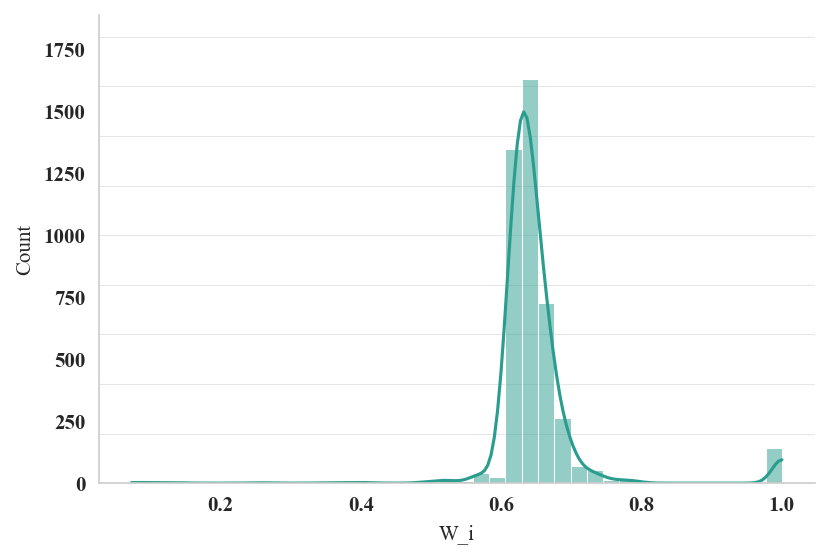

图已保存： c:\Users\Administrator\Desktop\正大杯\code\outputs\comment_weight_distribution.png


,comment_id,post_id,text_content,W_i,burst_risk
2637,5277452617122853,5277450619848968,深有同感！其实不用太有压力，把AI当成个好用的工具就行。哪怕只用来查资料、写个邮件草稿，能省...,0.072760,0.927240
2636,5277450730996393,5277450619848968,近期AI智能体资料整理大合集 OpenClaw 2026从小白到超级个体进化指南｜实战｜进阶...,0.072760,0.927240
3610,5277593393693765,5277593075975308,近期AI智能体资料整理大合集 OpenClaw 2026从小白到超级个体进化指南｜实战｜进阶...,0.087928,0.912072
3611,5277605727047398,5277593075975308,这个观点太有穿透力了！以前觉得人多力量大，现在看，AI时代确实更看重单点爆发力。从“人海战术...,0.087928,0.912072
3616,5277595425052213,5277595236042353,恭喜你成功部署！OpenClaw确实代表了AI从“能聊”到“能干”的关键转变，它作为“数字员...,0.110818,0.889182
3617,5277596851901137,5277595236042353,回复@千问:唉，小Q.!!!!,0.110818,0.889182
665,5276469561394806,5276469514209980,马斯克的xAI团队大变动，华人联合创始人全离开，留下马斯克和两位伙伴。,0.136624,0.863376
666,5276755767329078,5276469514209980,我感觉这次马斯克是因为他的ai团队里华人太多了，这才开启了大清洗，他认为这个大模型过度依赖华...,0.136624,0.863376
2484,5277445735321404,5277445204739176,学手艺永远不晚！AI虽厉害，但很多需要人情味、创意和精细操作的工作它还做不来。比如手工艺、烹...,0.254599,0.745401
2483,5277445499389067,5277445204739176,@投喂小宇宙 中午好我来互动一下！,0.254599,0.745401


In [66]:
# 联合优化后权重分布图
fig, ax = plt.subplots(figsize=(5.6, 3.8))

sns.histplot(
    result_df['W_i'].dropna(),
    bins=40,
    kde=True,
    ax=ax,
    color=青橙灰配色[0],
    edgecolor='white',
    linewidth=0.5,
)

for y_value in ax.get_yticks()[1:]:
    ax.axhline(y_value, color='#E6E6E6', linewidth=0.5, zorder=0)

应用整图字体(fig)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comment_weight_distribution.png', dpi=300)
plt.show()

print('图已保存：', OUTPUT_DIR / 'comment_weight_distribution.png')
display(
    result_df[['comment_id', 'post_id', 'text_content', 'W_i', 'burst_risk']]
    .sort_values('burst_risk', ascending=False)
    .head(10)
)

## 基于 $W_i$ 的评论赋权词云

这里直接使用优化后的 `result_df`。

> 对每条评论中的词，按该评论对应的 $W_i$ 进行加权累计。

> 因为 $W_i$ 越小代表越异常，所以这个词云更偏向“保留正常主体语义、压低异常/水军/模板化评论影响”。

> 若后续需要突出异常文本，可以再单独画一张按 $1-W_i$ 加权的异常词云。

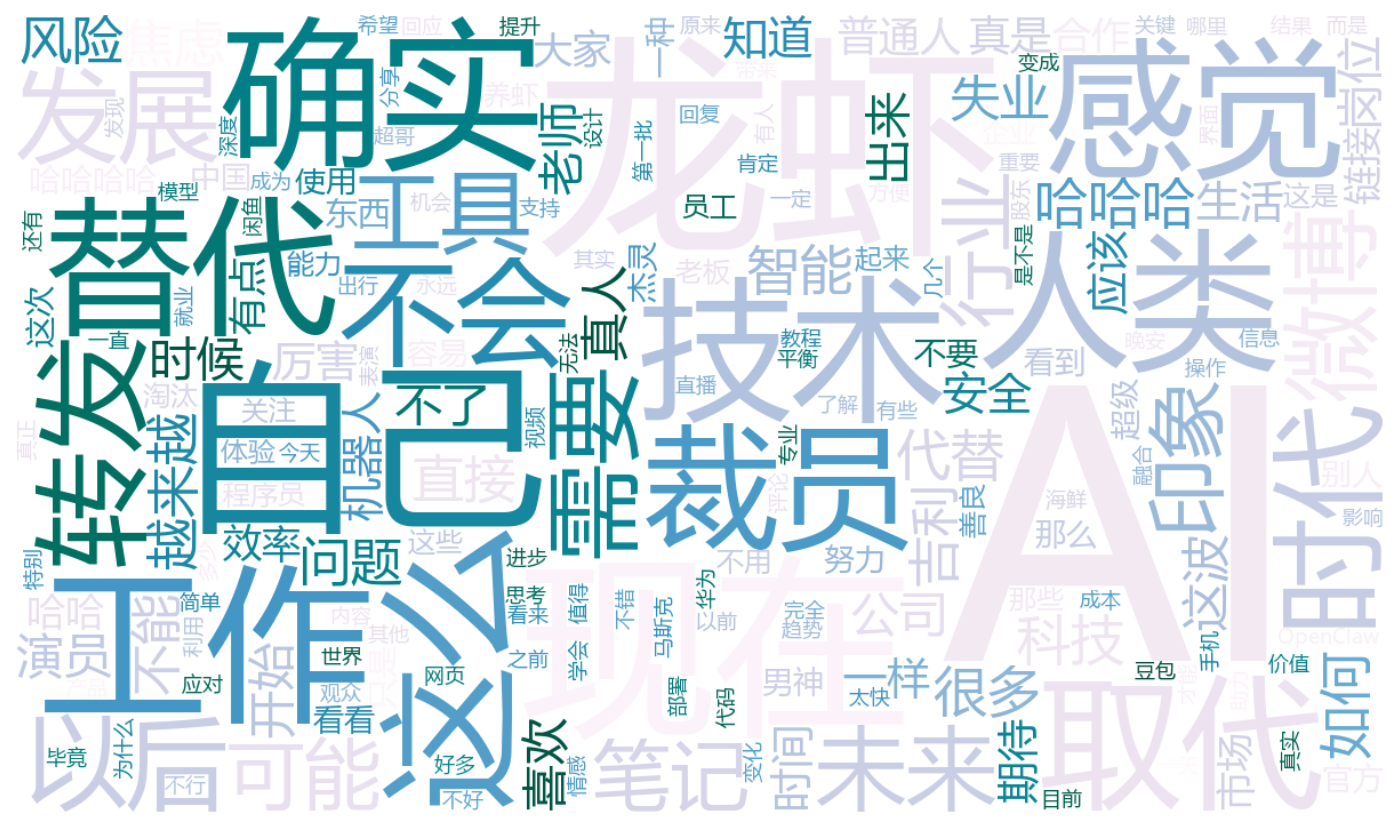

图已保存： c:\Users\Administrator\Desktop\正大杯\code\outputs\comment_weighted_wordcloud.png
按 $W_i$ 加权后的高频词（前 30 个）：


,word,weighted_freq_by_W_i
0,AI,707.021392
1,龙虾,177.495208
2,现在,121.601887
3,自己,106.862329
4,工作,87.598019
5,确实,82.120800
6,技术,74.071176
7,人类,70.334294
8,感觉,69.967876
9,替代,66.706981


In [ ]:
from collections import Counter

import jieba
from wordcloud import WordCloud


def pick_chinese_font():
    candidates = [
        Path('C:/Windows/Fonts/msyh.ttc'),
        Path('C:/Windows/Fonts/simhei.ttf'),
        Path('C:/Windows/Fonts/simsun.ttc'),
    ]
    for path in candidates:
        if path.exists():
            return str(path)
    raise FileNotFoundError('未找到可用的中文字体文件，请检查 Windows 字体目录。')


stopwords = {
    '的', '了', '是', '在', '也', '和', '都', '就', '又', '很',
    '把', '让', '还', '一个', '一下', '这个', '那个', '你', '我', '他',
    '她', '它', '我们', '你们', '他们', '她们', '以及', '然后', '就是', '还是',
    '因为', '所以', '如果', '而且', '但是', '不过', '真的', '觉得', '可以', '这种',
    '没有', '不是', '什么', '怎么', '这样', '那种', '已经', '非常', '比较', '一些',
}

weighted_counter = Counter()

for _, row in result_df[['clean_text', 'W_i']].dropna().iterrows():
    text = str(row['clean_text']).strip()
    weight = float(row['W_i'])
    if not text or weight <= 0:
        continue

    words = jieba.lcut(text)
    for word in words:
        word = word.strip()
        if len(word) < 2:
            continue
        if word.isdigit():
            continue
        if word.lower() in {'ai', 'openclaw'}:
            weighted_counter[word.upper() if word.lower() == 'ai' else word] += weight
            continue
        if re.fullmatch(r'[\W_]+', word):
            continue
        if word in stopwords:
            continue
        weighted_counter[word] += weight

font_path = pick_chinese_font()
top_weighted_words = pd.DataFrame(
    weighted_counter.most_common(50),
    columns=['word', 'weighted_freq_by_W_i'],
)

wc = WordCloud(
    font_path=font_path,
    width=1200,
    height=700,
    background_color='white',
    colormap='PuBuGn',
    max_words=200,
    prefer_horizontal=0.9,
    random_state=42,
).generate_from_frequencies(dict(weighted_counter))

fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
设置中文论文图表(ax, title='基于评论权重的主题词云')
应用整图字体(fig)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comment_weighted_wordcloud.png', dpi=300)
plt.show()

print('图已保存：', OUTPUT_DIR / 'comment_weighted_wordcloud.png')
print('按 $W_i$ 加权后的高频词（前 30 个）：')
display(top_weighted_words.head(30))

In [35]:
final_summary = {
    "rows": len(result_df),
    "W_i_min": float(result_df["W_i"].min()),
    "W_i_median": float(result_df["W_i"].median()),
    "W_i_p10": float(result_df["W_i"].quantile(0.1)),
    "W_i_max": float(result_df["W_i"].max()),
    "burst_risk_mean": float(result_df["burst_risk"].mean()),
    "burst_risk_p90": float(result_df["burst_risk"].quantile(0.9)),
    "burst_risk_max": float(result_df["burst_risk"].max()),
}
print(final_summary)

print("\n按 burst_risk 排序的高风险文本类型（前 30 个）:")
display(
    result_df.groupby("text_content", dropna=False)
    .agg(
        count=("comment_id", "size"),
        mean_W_i=("W_i", "mean"),
        mean_burst_risk=("burst_risk", "mean"),
        max_burst_risk=("burst_risk", "max"),
    )
    .sort_values(["mean_burst_risk", "count"], ascending=[False, False])
    .head(30)
)

print("\n按 burst_risk 排序的高风险帖子（前 15 个）:")
display(
    result_df.groupby("post_id")
    .agg(
        comments=("comment_id", "size"),
        mean_W_i=("W_i", "mean"),
        mean_burst_risk=("burst_risk", "mean"),
        max_burst_risk=("burst_risk", "max"),
    )
    .sort_values(["mean_burst_risk", "comments"], ascending=[False, False])
    .head(15)
)

{'rows': 4375, 'W_i_min': 0.07276021230672257, 'W_i_median': 0.6363539717274238, 'W_i_p10': 0.6115342225358857, 'W_i_max': 1.0, 'burst_risk_mean': 0.3492176761863823, 'burst_risk_p90': 0.38846577746411426, 'burst_risk_max': 0.9272397876932774}

按 burst_risk 排序的高风险文本类型（前 30 个）:


,count,mean_W_i,mean_burst_risk,max_burst_risk
text_content,,,,
深有同感！其实不用太有压力，把AI当成个好用的工具就行。哪怕只用来查资料、写个邮件草稿，能省点事就是赚到，慢慢来，别让工具反而成了负担。,1,0.072760,0.927240,0.927240
这个观点太有穿透力了！以前觉得人多力量大，现在看，AI时代确实更看重单点爆发力。从“人海战术”到“超级个体”，这种进化指南真的值得好好琢磨一下。,1,0.087928,0.912072,0.912072
回复@千问:唉，小Q.!!!!,1,0.110818,0.889182,0.889182
恭喜你成功部署！OpenClaw确实代表了AI从“能聊”到“能干”的关键转变，它作为“数字员工”能自主执行任务，正推动产业进入Agent时代。不过，随着这类智能体的普及，Token消耗量激增已成趋势，算力成本是当前行业面临的现实挑战，免费的无限量VIP可能很难实现啦~,1,0.110818,0.889182,0.889182
我感觉这次马斯克是因为他的ai团队里华人太多了，这才开启了大清洗，他认为这个大模型过度依赖华人团队（招聘过程也是华人招华人），这是较大的风险，因为美国可能不太会允许这种情况。这或许才是主因，所以马斯克想另外招白人团队！,1,0.136624,0.863376,0.863376
马斯克的xAI团队大变动，华人联合创始人全离开，留下马斯克和两位伙伴。,1,0.136624,0.863376,0.863376
@投喂小宇宙 中午好我来互动一下！,1,0.254599,0.745401,0.745401
学手艺永远不晚！AI虽厉害，但很多需要人情味、创意和精细操作的工作它还做不来。比如手工艺、烹饪、护理等，这些行业反而可能因为AI的普及而获得更多关注和需求哦。考虑转型或新技能是个明智的选择！,1,0.254599,0.745401,0.745401
AI的陪伴，让老年人感受到温暖与尊重。,1,0.353757,0.646243,0.646243



按 burst_risk 排序的高风险帖子（前 15 个）:


,comments,mean_W_i,mean_burst_risk,max_burst_risk
post_id,,,,
5277450619848968,2,0.072760,0.927240,0.927240
5277593075975308,2,0.087928,0.912072,0.912072
5277595236042353,2,0.110818,0.889182,0.889182
5276469514209980,2,0.136624,0.863376,0.863376
5277445204739176,2,0.254599,0.745401,0.745401
5273353959244421,2,0.353757,0.646243,0.646243
5277621253572471,2,0.381342,0.618658,0.618658
5276431736638266,3,0.405398,0.594602,0.594602
5277436633942151,2,0.489587,0.510413,0.510413


SVO 来源文件: c:\Users\Administrator\Desktop\正大杯\code\svo_extracted_results.json
网络边表已保存到: c:\Users\Administrator\Desktop\正大杯\code\outputs\svo_weighted_network_edges.csv
图已保存： c:\Users\Administrator\Desktop\正大杯\code\outputs\svo_weighted_network.png

按 strength 排序的三元组边（前 30 条）：


,subject,predicate,object,comment_count,sum_W_i,sum_like_count,strength,mean_burst_risk
0,AI时代,迎来,新拐点,1,0.683881,502.0,343.308124,0.316119
1,Meta,裁,两成员工,1,0.683881,502.0,343.308124,0.316119
2,行业转型,守住,从业者的温度,1,0.683881,500.0,341.940362,0.316119
3,AI,总结,观点,1,0.656178,227.0,148.952367,0.343822
4,他,会附和,你,1,0.656178,227.0,148.952367,0.343822
5,你,反驳,它的论点,1,0.656178,227.0,148.952367,0.343822
6,全员openclaw,会玩,梗,1,0.676742,217.0,146.853103,0.323258
7,程序员的快乐,是,简单,1,0.676742,217.0,146.853103,0.323258
8,AI,会造成,结构调整,1,0.630832,166.0,104.718075,0.369168
9,沟通类工种,是,难替代的,1,0.630832,166.0,104.718075,0.369168


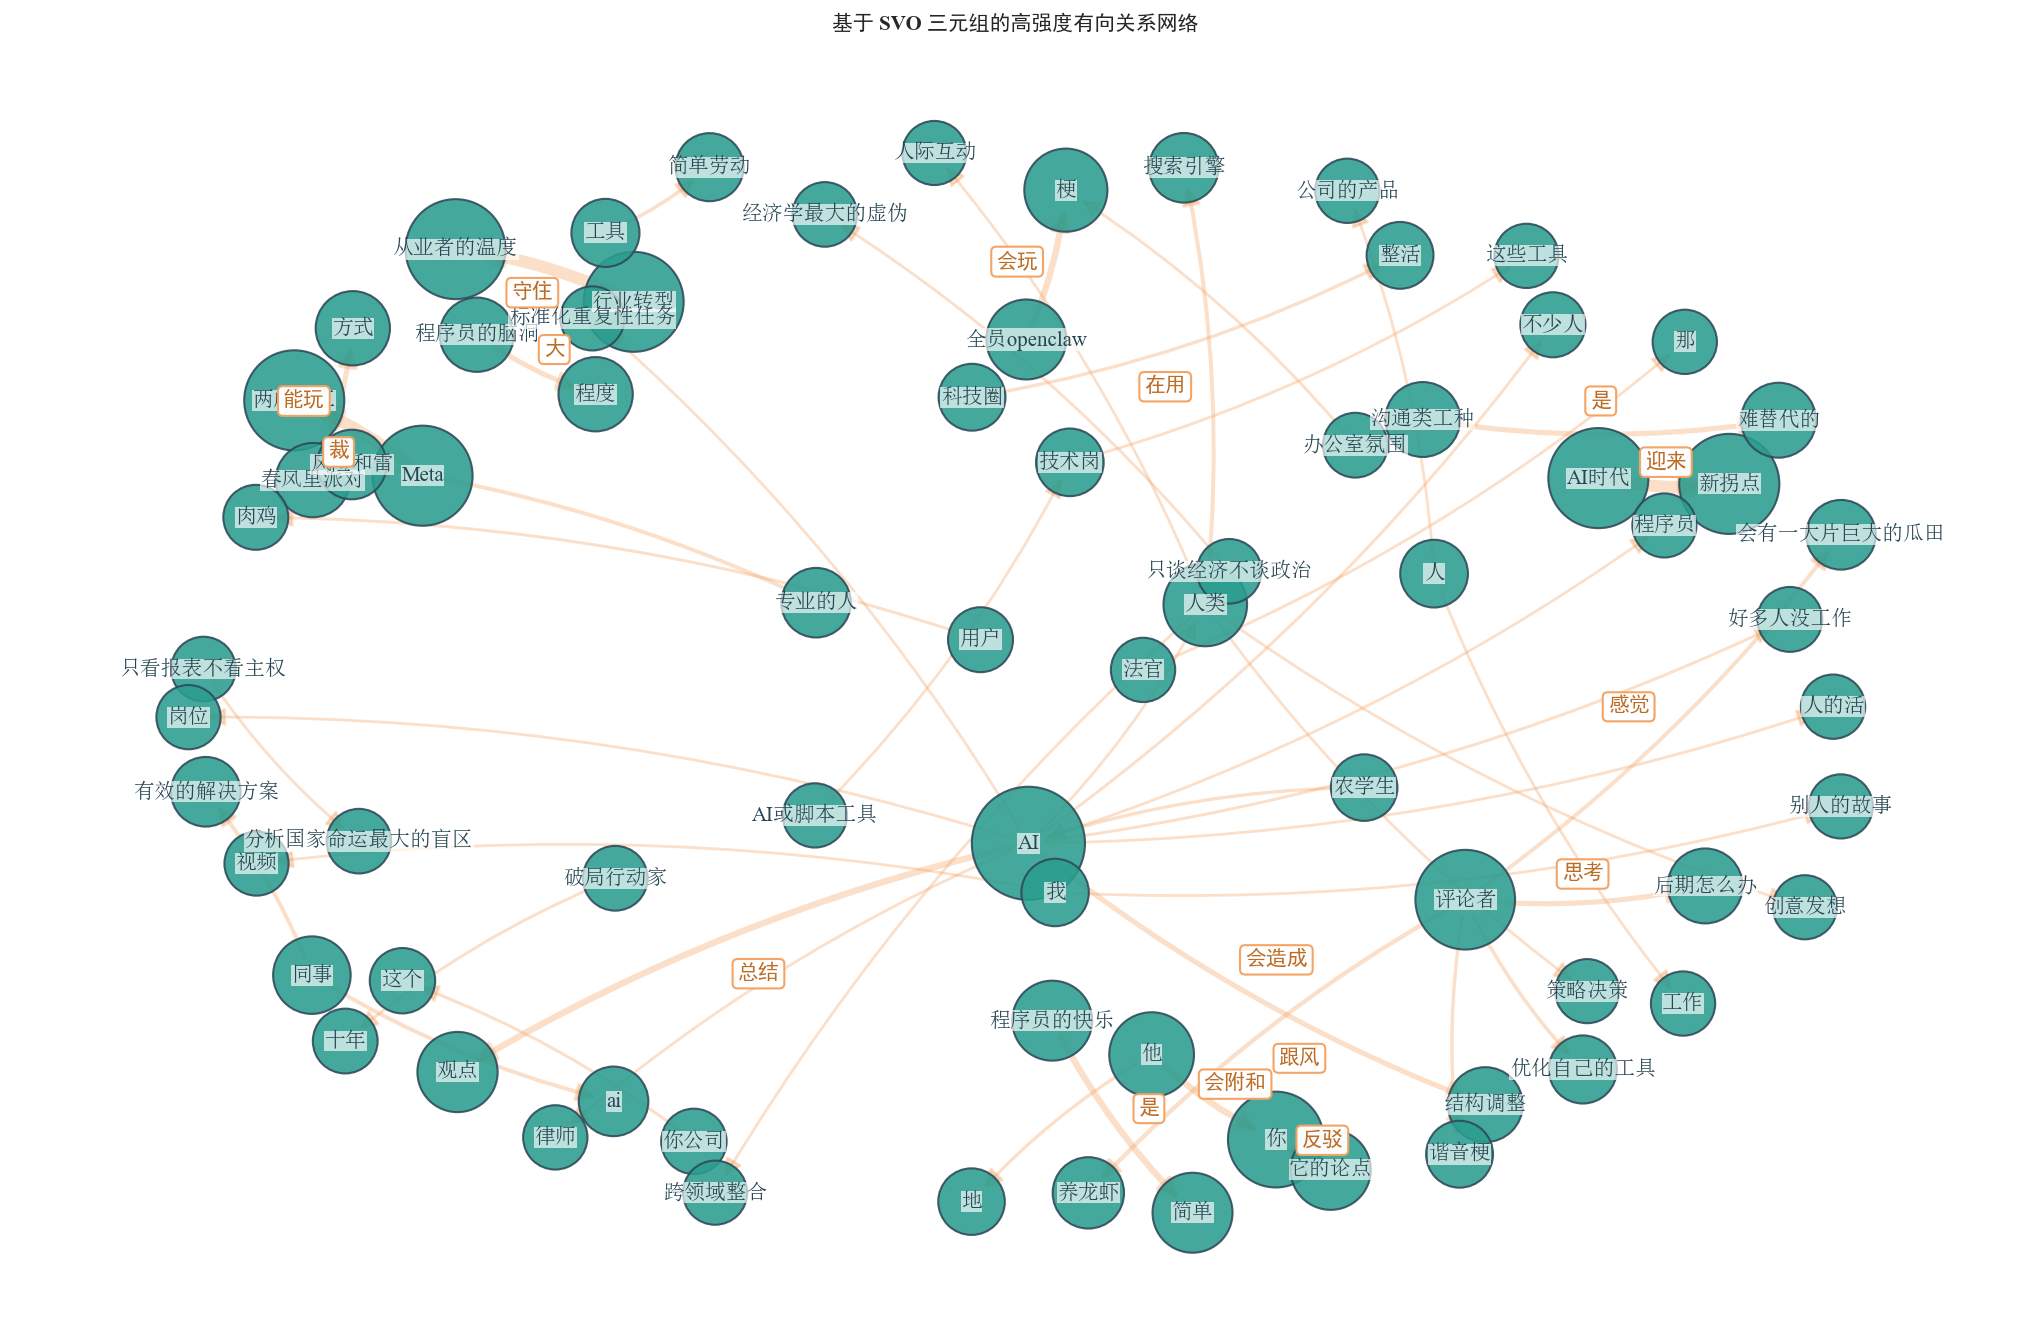

In [72]:
import networkx as nx


def load_svo_results():
    candidate_paths = [
        WORKDIR / 'svo_extracted_results.json',
        WORKDIR.parent / 'svo_extracted_results.json',
    ]
    for path in candidate_paths:
        if path.exists():
            with open(path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            if isinstance(data, dict) and 'results' in data:
                data = data['results']
            if not isinstance(data, list):
                raise ValueError(f'SVO 文件格式不正确: {path}')
            return path, data
    raise FileNotFoundError('未找到 svo_extracted_results.json，请先确认三元组抽取结果文件存在。')


def normalize_entity(value):
    value = normalize_text(value)
    value = re.sub(r'^回复@[^:：]+[:：]?', '', value)
    return value


def draw_triplet_network(edge_table, top_n=30, label_top_n=16):
    plot_edges = edge_table.head(top_n).copy().reset_index(drop=True)
    if plot_edges.empty:
        print('没有可绘制的三元组网络。')
        return

    graph = nx.DiGraph()
    for _, row in plot_edges.iterrows():
        subject = row['subject']
        obj = row['object']
        predicate = str(row['predicate']).strip()
        strength = float(row['strength'])

        if graph.has_edge(subject, obj):
            graph[subject][obj]['weight'] += strength
            existing_predicates = graph[subject][obj].get('predicate_list', [])
            if predicate and predicate not in existing_predicates:
                existing_predicates.append(predicate)
            graph[subject][obj]['predicate_list'] = existing_predicates
            graph[subject][obj]['predicate'] = ' / '.join(existing_predicates[:2])
        else:
            graph.add_edge(
                subject,
                obj,
                weight=strength,
                predicate=predicate,
                predicate_list=[predicate] if predicate else [],
            )

    pos = nx.spring_layout(graph, seed=42, k=1.75)
    degree_weight = dict(graph.degree(weight='weight'))
    max_degree_weight = max(degree_weight.values()) if degree_weight else 1.0
    edge_weight = nx.get_edge_attributes(graph, 'weight')
    max_edge_weight = max(edge_weight.values()) if edge_weight else 1.0

    node_sizes = [850 + 2100 * (degree_weight[node] / max_degree_weight) for node in graph.nodes()]
    edge_widths = [1.0 + 4.8 * (graph[u][v]['weight'] / max_edge_weight) for u, v in graph.edges()]

    fig, ax = plt.subplots(figsize=(13.6, 9.0))
    nx.draw_networkx_nodes(
        graph,
        pos,
        node_size=node_sizes,
        node_color=青橙灰配色[0],
        edgecolors='#2F4858',
        linewidths=1.0,
        alpha=0.88,
        ax=ax,
    )
    nx.draw_networkx_edges(
        graph,
        pos,
        width=edge_widths,
        edge_color=青橙灰配色[1],
        alpha=0.34,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=18,
        connectionstyle='arc3,rad=0.08',
        ax=ax,
    )
    nx.draw_networkx_labels(
        graph,
        pos,
        font_size=7.8,
        font_color='#264653',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.66, pad=0.12),
        ax=ax,
    )

    label_edges = plot_edges.head(label_top_n)
    edge_labels = {}
    for _, row in label_edges.iterrows():
        edge_key = (row['subject'], row['object'])
        predicate = str(row['predicate']).strip()
        if not predicate:
            continue
        if edge_key in edge_labels:
            if predicate not in edge_labels[edge_key]:
                edge_labels[edge_key] = f"{edge_labels[edge_key]} / {predicate}"
        else:
            edge_labels[edge_key] = predicate

    for (u, v), label in edge_labels.items():
        if u not in pos or v not in pos:
            continue
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        mid_x = (x1 + x2) / 2
        mid_y = (y1 + y2) / 2
        dx = x2 - x1
        dy = y2 - y1
        norm = np.hypot(dx, dy)
        if norm == 0:
            norm = 1.0
        offset_scale = 0.035
        offset_x = -dy / norm * offset_scale
        offset_y = dx / norm * offset_scale

        text = ax.text(
            mid_x + offset_x,
            mid_y + offset_y,
            label,
            fontsize=11,
            color='#BC6C25',
            ha='center',
            va='center',
            fontweight='bold',
            zorder=8,
            bbox=dict(
                facecolor='white',
                edgecolor='#F4A261',
                boxstyle='round,pad=0.24',
                alpha=0.98,
                linewidth=1.0,
            ),
        )
        text.set_fontproperties(正文字体)
        text.set_fontweight('bold')

    设置中文论文图表(ax, title='基于 SVO 三元组的高强度有向关系网络')
    ax.axis('off')
    应用整图字体(fig)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'svo_weighted_network.png', dpi=300)
    plt.show()


svo_path, svo_results = load_svo_results()
comment_meta = result_df[['comment_id', 'like_count', 'W_i', 'burst_risk']].copy()
comment_meta['comment_id'] = comment_meta['comment_id'].astype(str)
comment_meta_map = comment_meta.set_index('comment_id').to_dict(orient='index')

triple_records = []
for item in svo_results:
    comment_id = str(item.get('comment_id', '')).strip()
    meta = comment_meta_map.get(comment_id)
    if meta is None:
        continue

    triples = item.get('triples', []) or []
    for triple in triples:
        subject = normalize_entity(triple.get('subject', ''))
        predicate = normalize_text(triple.get('predicate', ''))
        obj = normalize_entity(triple.get('object', ''))
        polarity_value = pd.to_numeric(triple.get('polarity', 1), errors='coerce')
        polarity = int(polarity_value) if pd.notna(polarity_value) else 1
        if not subject or not predicate or not obj:
            continue

        like_value = pd.to_numeric(meta.get('like_count', 0), errors='coerce')
        weight_value = pd.to_numeric(meta.get('W_i', 1), errors='coerce')
        burst_value = pd.to_numeric(meta.get('burst_risk', 0), errors='coerce')
        like_count = float(like_value) if pd.notna(like_value) else 0.0
        weight = float(weight_value) if pd.notna(weight_value) else 1.0
        burst_risk = float(burst_value) if pd.notna(burst_value) else 0.0

        triple_records.append({
            'comment_id': comment_id,
            'subject': subject,
            'predicate': predicate,
            'object': obj,
            'polarity': polarity,
            'like_count': like_count,
            'W_i': weight,
            'burst_risk': burst_risk,
            'strength_contribution': like_count * weight,
        })

triple_df = pd.DataFrame(triple_records)
if triple_df.empty:
    raise ValueError('三元组为空，无法构建网络图。')

edge_summary = (
    triple_df.groupby(['subject', 'predicate', 'object'], dropna=False)
    .agg(
        comment_count=('comment_id', 'nunique'),
        sum_W_i=('W_i', 'sum'),
        sum_like_count=('like_count', 'sum'),
        strength=('strength_contribution', 'sum'),
        mean_burst_risk=('burst_risk', 'mean'),
    )
    .reset_index()
    .sort_values(['strength', 'comment_count', 'sum_W_i'], ascending=[False, False, False])
    .reset_index(drop=True)
)

edge_output_path = OUTPUT_DIR / 'svo_weighted_network_edges.csv'
edge_summary.to_csv(edge_output_path, index=False, encoding='utf-8-sig')

print(f'SVO 来源文件: {svo_path}')
print(f'网络边表已保存到: {edge_output_path}')
print('图已保存：', OUTPUT_DIR / 'svo_weighted_network.png')
print('\n按 strength 排序的三元组边（前 30 条）：')
display(edge_summary.head(30))

draw_triplet_network(edge_summary, top_n=50, label_top_n=16)

边强度筛选分位数: 0.85
边强度阈值: 1.278466
完整无向图: 3789 个节点, 3795 条边
筛选后无向图: 764 个节点, 622 条边
Louvain 节点表已保存到: c:\Users\Administrator\Desktop\正大杯\code\outputs\svo_louvain_nodes.csv
Louvain 社区汇总已保存到: c:\Users\Administrator\Desktop\正大杯\code\outputs\svo_louvain_communities.csv
Louvain 筛选边表已保存到: c:\Users\Administrator\Desktop\正大杯\code\outputs\svo_louvain_filtered_edges.csv
图已保存： c:\Users\Administrator\Desktop\正大杯\code\outputs\svo_louvain_network.png
识别出的社区数量: 198

社区汇总：


,community_id,node_count,total_weighted_degree
0,59,91,1663.537087
1,3,80,1933.050294
2,4,34,1062.873828
3,20,28,403.596908
4,18,25,338.071646
...,...,...,...
193,137,1,4.371962
194,172,1,2.668254
195,179,1,2.641825
196,183,1,2.627672



节点社区归属（前 50 条）：


,node,community_id,weighted_degree
0,AI时代,0,343.308124
1,新拐点,0,343.308124
2,Meta,1,343.308124
3,两成员工,1,343.308124
4,从业者的温度,2,341.940362
5,行业转型,2,341.940362
6,AI,3,772.998402
7,人类,3,240.601089
8,观点,3,155.317003
9,结构调整,3,104.718075



参与 Louvain 的高强度边（前 50 条）：


,subject,predicate,object,comment_count,sum_W_i,sum_like_count,strength,mean_burst_risk,source_community,target_community
0,AI时代,迎来,新拐点,1,0.683881,502.0,343.308124,0.316119,0,0
1,Meta,裁,两成员工,1,0.683881,502.0,343.308124,0.316119,1,1
2,行业转型,守住,从业者的温度,1,0.683881,500.0,341.940362,0.316119,2,2
3,AI,总结,观点,1,0.656178,227.0,148.952367,0.343822,3,3
4,他,会附和,你,1,0.656178,227.0,148.952367,0.343822,4,4
5,你,反驳,它的论点,1,0.656178,227.0,148.952367,0.343822,4,4
6,全员openclaw,会玩,梗,1,0.676742,217.0,146.853103,0.323258,5,5
7,程序员的快乐,是,简单,1,0.676742,217.0,146.853103,0.323258,6,6
8,AI,会造成,结构调整,1,0.630832,166.0,104.718075,0.369168,3,3
9,沟通类工种,是,难替代的,1,0.630832,166.0,104.718075,0.369168,7,7


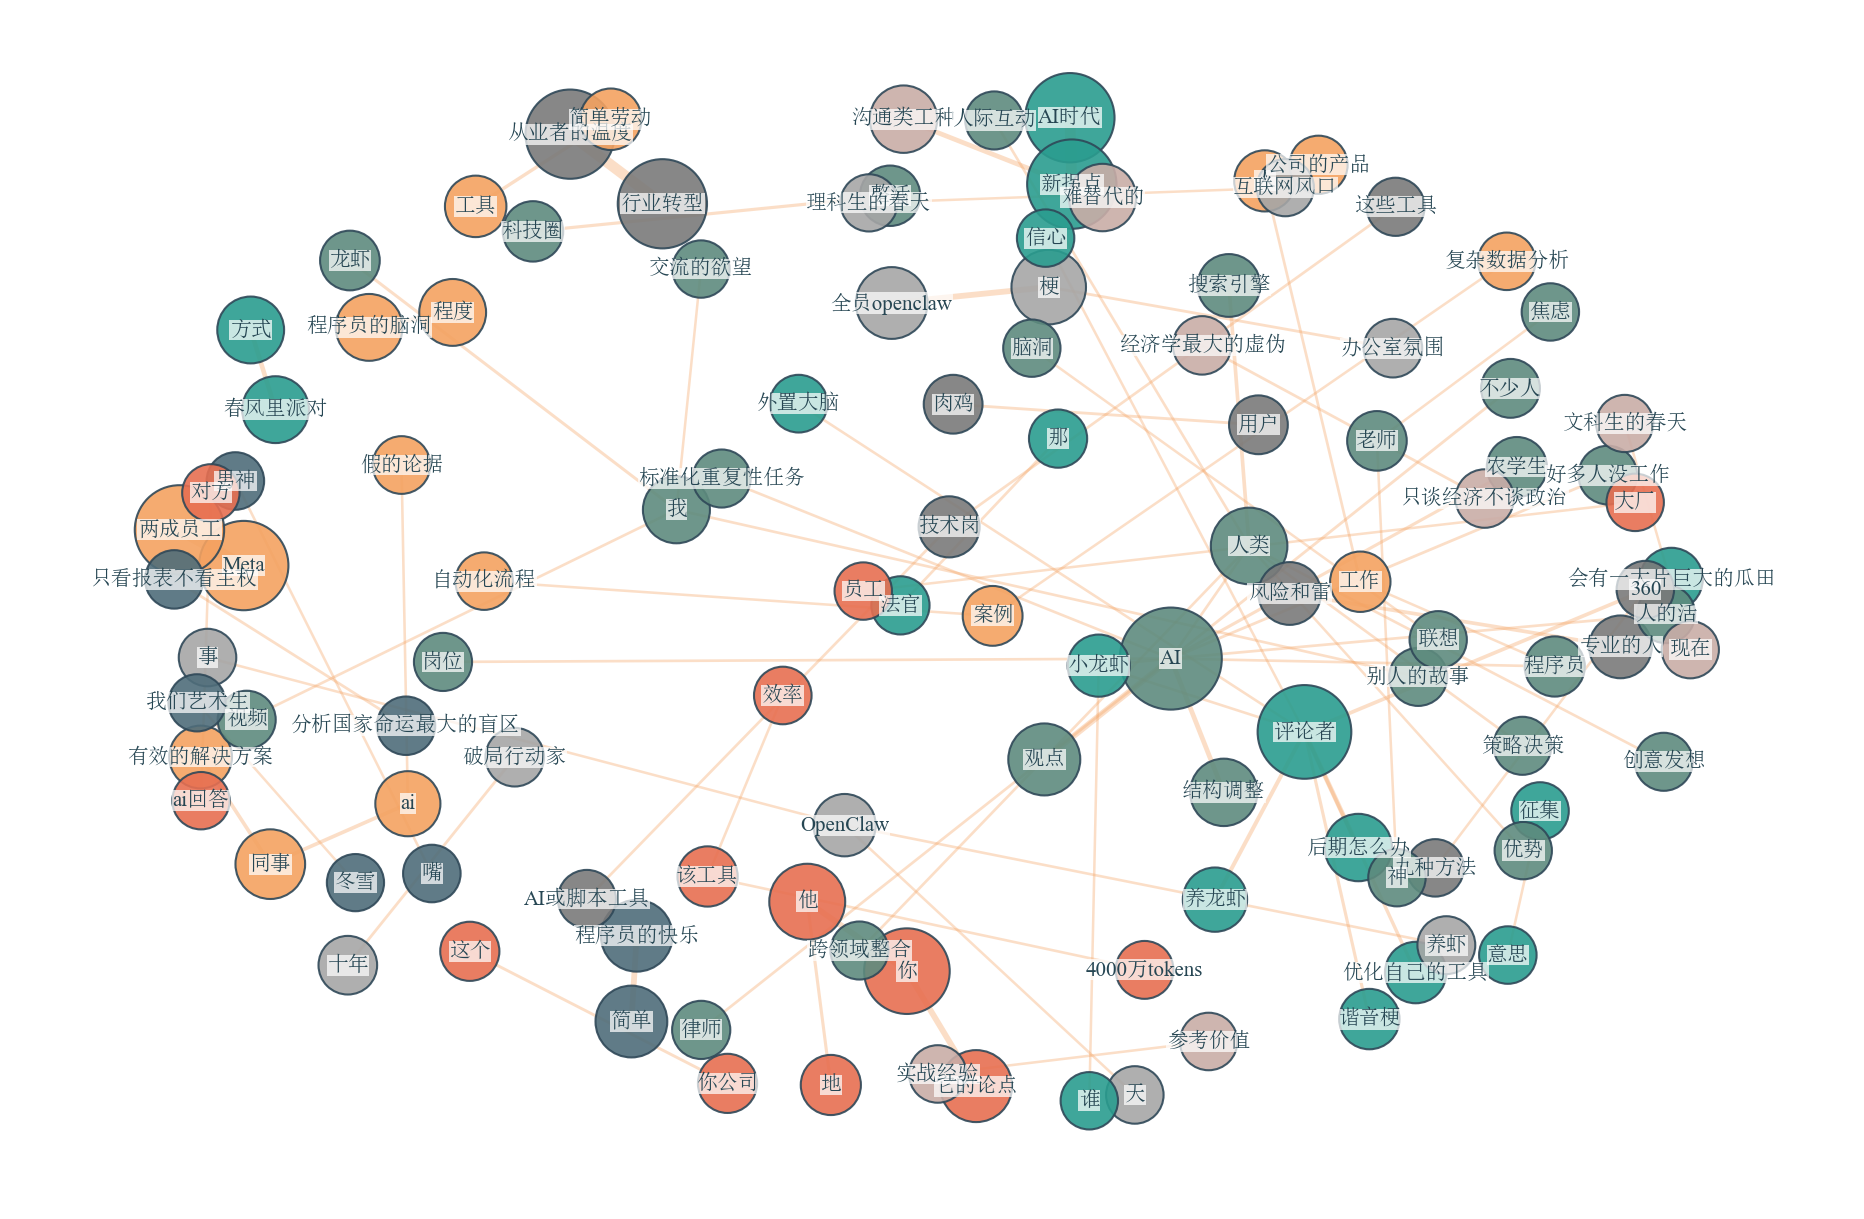

In [68]:
COMMUNITY_EDGE_QUANTILE = 0.85
COMMUNITY_RESOLUTION = 0.8

community_graph_full = nx.Graph()
for _, row in edge_summary.iterrows():
    u = row['subject']
    v = row['object']
    w = float(row['strength'])
    if community_graph_full.has_edge(u, v):
        community_graph_full[u][v]['weight'] += w
    else:
        community_graph_full.add_edge(u, v, weight=w)

edge_strength_threshold = float(edge_summary['strength'].quantile(COMMUNITY_EDGE_QUANTILE))
filtered_edge_summary = edge_summary[edge_summary['strength'] >= edge_strength_threshold].copy()

community_graph = nx.Graph()
for _, row in filtered_edge_summary.iterrows():
    u = row['subject']
    v = row['object']
    w = float(row['strength'])
    if community_graph.has_edge(u, v):
        community_graph[u][v]['weight'] += w
    else:
        community_graph.add_edge(u, v, weight=w)

if community_graph.number_of_edges() == 0:
    raise ValueError('筛选后社区图为空，请降低边强度阈值。')

louvain_communities = nx.community.louvain_communities(
    community_graph,
    weight='weight',
    seed=42,
    resolution=COMMUNITY_RESOLUTION,
)

node_to_community = {}
for community_id, members in enumerate(louvain_communities):
    for node in members:
        node_to_community[node] = community_id

node_summary = pd.DataFrame({
    'node': list(node_to_community.keys()),
    'community_id': list(node_to_community.values()),
})
node_summary['weighted_degree'] = node_summary['node'].map(dict(community_graph.degree(weight='weight'))).astype(float)
node_summary = node_summary.sort_values(['community_id', 'weighted_degree'], ascending=[True, False]).reset_index(drop=True)

community_summary = (
    node_summary.groupby('community_id', dropna=False)
    .agg(
        node_count=('node', 'size'),
        total_weighted_degree=('weighted_degree', 'sum'),
    )
    .reset_index()
    .sort_values(['node_count', 'total_weighted_degree'], ascending=[False, False])
    .reset_index(drop=True)
)

community_edge_summary = filtered_edge_summary.copy()
community_edge_summary['source_community'] = community_edge_summary['subject'].map(node_to_community)
community_edge_summary['target_community'] = community_edge_summary['object'].map(node_to_community)

node_output_path = OUTPUT_DIR / 'svo_louvain_nodes.csv'
community_output_path = OUTPUT_DIR / 'svo_louvain_communities.csv'
filtered_edge_output_path = OUTPUT_DIR / 'svo_louvain_filtered_edges.csv'
node_summary.to_csv(node_output_path, index=False, encoding='utf-8-sig')
community_summary.to_csv(community_output_path, index=False, encoding='utf-8-sig')
community_edge_summary.to_csv(filtered_edge_output_path, index=False, encoding='utf-8-sig')


def draw_louvain_communities(node_to_community, edge_table, top_n=80):
    plot_edges = edge_table.head(top_n).copy()
    if plot_edges.empty:
        print('没有可绘制的社区网络。')
        return

    plot_graph = nx.Graph()
    for _, row in plot_edges.iterrows():
        u = row['subject']
        v = row['object']
        w = float(row['strength'])
        if plot_graph.has_edge(u, v):
            plot_graph[u][v]['weight'] += w
        else:
            plot_graph.add_edge(u, v, weight=w)

    communities = sorted({node_to_community[node] for node in plot_graph.nodes() if node in node_to_community})
    palette = 青橙灰配色[:8]
    color_map = {community: palette[i % len(palette)] for i, community in enumerate(communities)}

    pos = nx.spring_layout(plot_graph, seed=42, k=1.8)
    degree_weight = dict(plot_graph.degree(weight='weight'))
    max_degree_weight = max(degree_weight.values()) if degree_weight else 1.0
    node_sizes = [700 + 1700 * (degree_weight[node] / max_degree_weight) for node in plot_graph.nodes()]
    node_colors = [color_map.get(node_to_community.get(node, -1), '#BFC8D6') for node in plot_graph.nodes()]
    max_weight = max(nx.get_edge_attributes(plot_graph, 'weight').values()) if plot_graph.number_of_edges() else 1.0
    edge_widths = [1.0 + 4.2 * (plot_graph[u][v]['weight'] / max_weight) for u, v in plot_graph.edges()]

    fig, ax = plt.subplots(figsize=(12.5, 8.2))
    nx.draw_networkx_nodes(
        plot_graph,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors='#2F4858',
        linewidths=1.0,
        alpha=0.9,
        ax=ax,
    )
    nx.draw_networkx_edges(
        plot_graph,
        pos,
        width=edge_widths,
        edge_color=青橙灰配色[1],
        alpha=0.35,
        ax=ax,
    )
    nx.draw_networkx_labels(
        plot_graph,
        pos,
        font_size=9,
        font_color='#264653',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.72, pad=0.15),
        ax=ax,
    )

    ax.axis('off')
    应用整图字体(fig)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'svo_louvain_network.png', dpi=300)
    plt.show()


print(f'边强度筛选分位数: {COMMUNITY_EDGE_QUANTILE}')
print(f'边强度阈值: {edge_strength_threshold:.6f}')
print(f'完整无向图: {community_graph_full.number_of_nodes()} 个节点, {community_graph_full.number_of_edges()} 条边')
print(f'筛选后无向图: {community_graph.number_of_nodes()} 个节点, {community_graph.number_of_edges()} 条边')
print(f'Louvain 节点表已保存到: {node_output_path}')
print(f'Louvain 社区汇总已保存到: {community_output_path}')
print(f'Louvain 筛选边表已保存到: {filtered_edge_output_path}')
print('图已保存：', OUTPUT_DIR / 'svo_louvain_network.png')
print(f'识别出的社区数量: {len(louvain_communities)}')
print('\n社区汇总：')
display(community_summary)
print('\n节点社区归属（前 50 条）：')
display(node_summary.head(50))
print('\n参与 Louvain 的高强度边（前 50 条）：')
display(community_edge_summary.head(50))

draw_louvain_communities(node_to_community, community_edge_summary, top_n=80)

前 5 个最大社区主题表已保存到: c:\Users\Administrator\Desktop\正大杯\code\outputs\svo_louvain_top5_themes.csv
图已保存： c:\Users\Administrator\Desktop\正大杯\code\outputs\svo_top5_community_subgraphs.png

前 5 个最大社区及主题词：


,community_id,node_count,total_weighted_degree,theme_words
0,59,91,1663.537087,后期怎么办 / 养龙虾 / 会有一大片巨大的瓜田 / 小龙虾
1,3,80,1933.050294,AI / 人类 / 结构调整 / 搜索引擎
2,4,34,1062.873828,它的论点 / 员工 / 公司 / 大厂
3,20,28,403.596908,龙虾 / 联想 / 视频 / 别人的故事
4,18,25,338.071646,工作 / 公司的产品 / 普通人 / 未来



前 5 个最大社区的代表节点（前 60 条）：


,node,community_id,weighted_degree
6,AI,3,772.998402
7,人类,3,240.601089
8,观点,3,155.317003
9,结构调整,3,104.718075
10,搜索引擎,3,64.919322
11,程序员,3,43.508212
12,农学生,3,40.373234
13,不少人,3,29.651717
14,好多人没工作,3,28.600943
15,岗位,3,25.100298


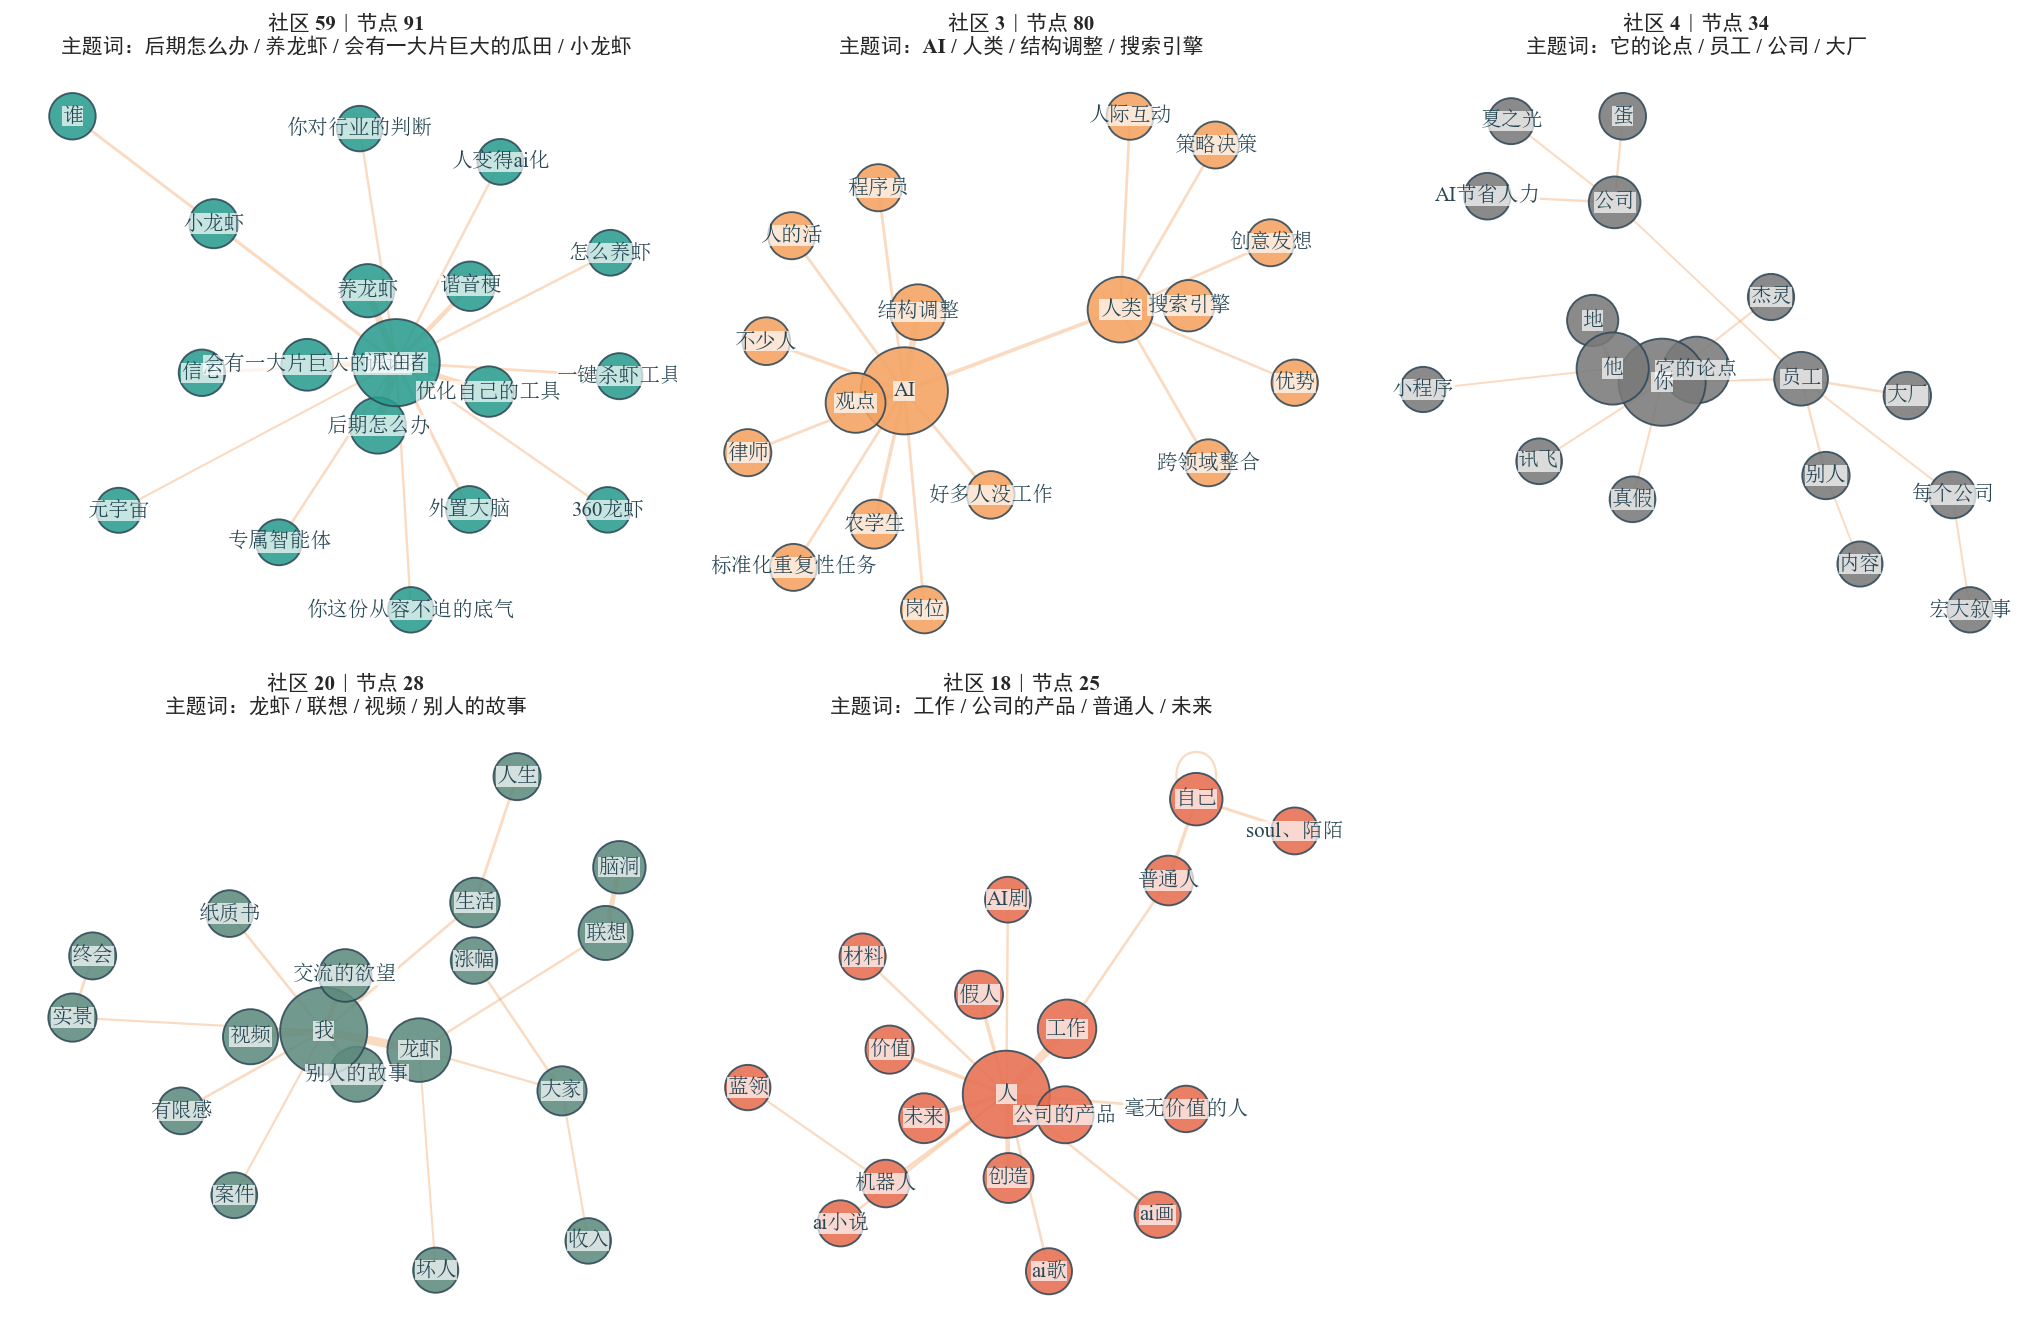

In [69]:
TOP_COMMUNITY_COUNT = 5
TOP_THEME_WORDS = 4
TOP_COMMUNITY_NODES_TO_DRAW = 18

GENERIC_THEME_WORDS = {
    '你', '我', '他', '她', '它', '我们', '你们', '他们', '她们',
    '评论者', '观点', '看法', '东西', '那个', '这个', '大家', '有人',
    '自己', '别人', '方式', '问题', '内容', '工具', '用户',
}


def extract_community_theme_words(node_df, community_id, top_k=4):
    candidates = (
        node_df[node_df['community_id'] == community_id]
        .sort_values('weighted_degree', ascending=False)['node']
        .tolist()
    )

    theme_words = []
    for word in candidates:
        word = str(word).strip()
        if len(word) < 2:
            continue
        if word in GENERIC_THEME_WORDS:
            continue
        if re.fullmatch(r'[\W_]+', word):
            continue
        if word not in theme_words:
            theme_words.append(word)
        if len(theme_words) >= top_k:
            break

    if len(theme_words) < 3:
        fallback_words = [str(word).strip() for word in candidates if str(word).strip() and str(word).strip() not in theme_words]
        for word in fallback_words:
            theme_words.append(word)
            if len(theme_words) >= top_k:
                break

    return theme_words[:top_k]


def draw_top_community_subgraphs(graph, node_df, community_df, top_n=5, max_nodes=18):
    top_communities = community_df.head(top_n)['community_id'].tolist()
    if not top_communities:
        print('没有可展示的社区。')
        return

    palette = 青橙灰配色[:top_n]
    fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.8), constrained_layout=True)
    axes = axes.flatten()

    for ax in axes[top_n:]:
        ax.axis('off')

    for idx, community_id in enumerate(top_communities):
        ax = axes[idx]
        community_nodes = (
            node_df[node_df['community_id'] == community_id]
            .sort_values('weighted_degree', ascending=False)
            .head(max_nodes)
        )
        selected_nodes = community_nodes['node'].tolist()
        subgraph = graph.subgraph(selected_nodes).copy()

        if subgraph.number_of_nodes() == 0:
            ax.axis('off')
            continue

        pos = nx.spring_layout(subgraph, seed=42, k=1.2)
        degree_weight = dict(subgraph.degree(weight='weight'))
        max_degree_weight = max(degree_weight.values()) if degree_weight else 1.0
        node_sizes = [450 + 1300 * (degree_weight[node] / max_degree_weight) for node in subgraph.nodes()]
        edge_weights = nx.get_edge_attributes(subgraph, 'weight')
        max_edge_weight = max(edge_weights.values()) if edge_weights else 1.0
        edge_widths = [0.8 + 3.4 * (subgraph[u][v]['weight'] / max_edge_weight) for u, v in subgraph.edges()]

        nx.draw_networkx_nodes(
            subgraph,
            pos,
            node_size=node_sizes,
            node_color=palette[idx % len(palette)],
            edgecolors='#2F4858',
            linewidths=0.9,
            alpha=0.88,
            ax=ax,
        )
        nx.draw_networkx_edges(
            subgraph,
            pos,
            width=edge_widths,
            edge_color=青橙灰配色[1],
            alpha=0.38,
            ax=ax,
        )
        nx.draw_networkx_labels(
            subgraph,
            pos,
            font_size=8.5,
            font_color='#264653',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.70, pad=0.12),
            ax=ax,
        )

        theme_words = extract_community_theme_words(node_df, community_id, top_k=TOP_THEME_WORDS)
        node_count = int(community_df.loc[community_df['community_id'] == community_id, 'node_count'].iloc[0])
        theme_text = ' / '.join(theme_words)
        设置中文论文图表(ax, title=f'社区 {community_id}｜节点 {node_count}\n主题词：{theme_text}')
        ax.axis('off')

    应用整图字体(fig)
    plt.savefig(OUTPUT_DIR / 'svo_top5_community_subgraphs.png', dpi=300)
    plt.show()


top5_community_summary = community_summary.head(TOP_COMMUNITY_COUNT).copy()
top5_community_summary['theme_words'] = top5_community_summary['community_id'].map(
    lambda cid: ' / '.join(extract_community_theme_words(node_summary, cid, top_k=TOP_THEME_WORDS))
)

top5_community_nodes = node_summary[node_summary['community_id'].isin(top5_community_summary['community_id'])]
community_theme_output_path = OUTPUT_DIR / 'svo_louvain_top5_themes.csv'
top5_community_summary.to_csv(community_theme_output_path, index=False, encoding='utf-8-sig')

print(f'前 5 个最大社区主题表已保存到: {community_theme_output_path}')
print('图已保存：', OUTPUT_DIR / 'svo_top5_community_subgraphs.png')
print('\n前 5 个最大社区及主题词：')
display(top5_community_summary)
print('\n前 5 个最大社区的代表节点（前 60 条）：')
display(top5_community_nodes.head(60))

draw_top_community_subgraphs(
    community_graph,
    node_summary,
    top5_community_summary,
    top_n=TOP_COMMUNITY_COUNT,
    max_nodes=TOP_COMMUNITY_NODES_TO_DRAW,
)